# Assignment: Data Wrangling

### Reading material: `tidy_data.pdf`

**Q1.** This question provides some practice cleaning variables which have common problems.
1. For `./data/airbnb_hw.csv`, clean the `Price` variable as well as you can, and explain the choices you make. How many missing values do you end up with? (Hint: What happens to the formatting when a price goes over 999 dollars, say from 675 to 1,112?)
2. For the Minnesota police use of for data, `./data/mn_police_use_of_force.csv`, clean the `subject_injury` variable, handling the NA's; this gives a value `Yes` when a person was injured by police, and `No` when no injury occurred. What proportion of the values are missing? Is this a concern? Cross-tabulate your cleaned `subject_injury` variable with the `force_type` variable. Are there any patterns regarding when the data are missing? 

**Q2.** Go to https://sharkattackfile.net/ and download their dataset on shark attacks (Hint: `GSAF5.xls`).

1. Open the shark attack file using Pandas. It is probably not a csv file, so `read_csv` won't work.
2. Drop any columns that do not contain data.
3. Clean the year variable. Describe the range of values you see. Filter the rows to focus on attacks since 1940. Are attacks increasing, decreasing, or remaining constant over time?
4. Clean the Age variable and make a histogram of the ages of the victims.
5. What proportion of victims are male?
6. Clean the `Type` variable so it only takes three values: Provoked and Unprovoked and Unknown. What proportion of attacks are unprovoked?

---

## *Phase 1: Solution without AI

Complete all questions in the following cells without generative AI. Then commit and push the
notebook before beginning Phase 2.

**Declaration:** I completed this version without generative AI.

**Student(s):** Geethan Sundaram

**Date:** 9/3/2026

In [48]:
# Your Phase 1 solution to the problem goes here.
import pandas as pd
import numpy as np

# Q1.1
print("****************Q1.1****************")

# Load airbnb data
airbnb_hw = pd.read_csv('data/airbnb_hw.csv')

# Check the data types and unique values of the Price variable
print("\nData types: ", airbnb_hw['Price'].dtype)
print("Unique values: ", airbnb_hw['Price'].unique()[:20])

# Check basic stats of the Price variable
print("\nBasic stats: ")
print(airbnb_hw['Price'].describe())

# Check first few rows of the Price variable
print("\nFirst few rows: ")
print(airbnb_hw['Price'].head())

# Check for missing values in the Price variable
print("\nMissing values before: ", airbnb_hw['Price'].isna().sum())

# Clean the 'Price' variable by removing commas and converting to numeric
airbnb_hw['Price_cleaned'] = (airbnb_hw['Price'].str.replace(',', '', regex=False))
airbnb_hw['Price_cleaned'] = pd.to_numeric(airbnb_hw['Price_cleaned'], errors='coerce')

# Check the cleaned Price variable first feq rows
print("\nCleaned Price variable: ")
print(airbnb_hw['Price_cleaned'].head())

# Check the stats and check for missing values in the cleaned Price variable
print("\nCleaned Price variable stats: ")
print(airbnb_hw['Price_cleaned'].describe())
print("\nMissing values after: ", airbnb_hw['Price_cleaned'].isna().sum())

# 

# Q1.2
print("\n\n****************Q1.2****************")

# Load police data
police_data = pd.read_csv('data/mn_police_use_of_force.csv')

# Check data types and unique values of the subject_injury variable
print("\nUnique values: ", police_data['subject_injury'].unique())
print("Value counts: ", police_data['subject_injury'].value_counts(dropna=False))

# Clean the subject_injury  variable by stripping whitespace and converting to string
police_data["subject_injury_cleaned"] = (
    police_data["subject_injury"]
    .astype("string")
    .str.strip()
)

# Clean the subject_injury_cleaned variable by keeping only "Yes" and "No" values and settin others to NaN
police_data["subject_injury_cleaned"] = police_data["subject_injury_cleaned"].where(
    police_data["subject_injury_cleaned"].isin(["Yes", "No"]),
    pd.NA
)

# Missing indicator for subject_injury_cleaned
missing_proportion = police_data["subject_injury_cleaned"].isna().mean()
print("\nProportion missing:", missing_proportion)
print("Percent missing:", missing_proportion * 100)


# Make cross-tabulations
police_data["subject_injury_table"] = (
    police_data["subject_injury_cleaned"].fillna("Missing")
)

print()
print(
    pd.crosstab(
        police_data["force_type"],
        police_data["subject_injury_table"]
    )
)

****************Q1.1****************

Data types:  object
Unique values:  ['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125']

Basic stats: 
count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object

First few rows: 
0    145
1     37
2     28
3    199
4    549
Name: Price, dtype: object

Missing values before:  0

Cleaned Price variable: 
0    145
1     37
2     28
3    199
4    549
Name: Price_cleaned, dtype: int64

Cleaned Price variable stats: 
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price_cleaned, dtype: float64

Missing values after:  0


****************Q1.2****************

Unique values:  [nan 'No' 'Yes']
Value counts:  subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

Proportion missing: 0.7619342359767892
Percent

**************** Part 1 ****************
(7117, 23)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')


**************** Part 2 ****************
Date              7117
Year              7115
Type              7099
Country           7067
State             6630
Location          6550
Activity          6534
Name              6899
Sex               6539
Age               4123
Injury            7081
Fatal Y/N         6556
Time              3590
Species           3986
Source            7097
pdf               6799
href formula      6794
href              6796
Case Number       6798
Case Number.1     6797
original order    6799
Unnamed: 21          1
Unnamed: 22          2
dtype: int64


**************** Part 3 ****************
count    7115.0

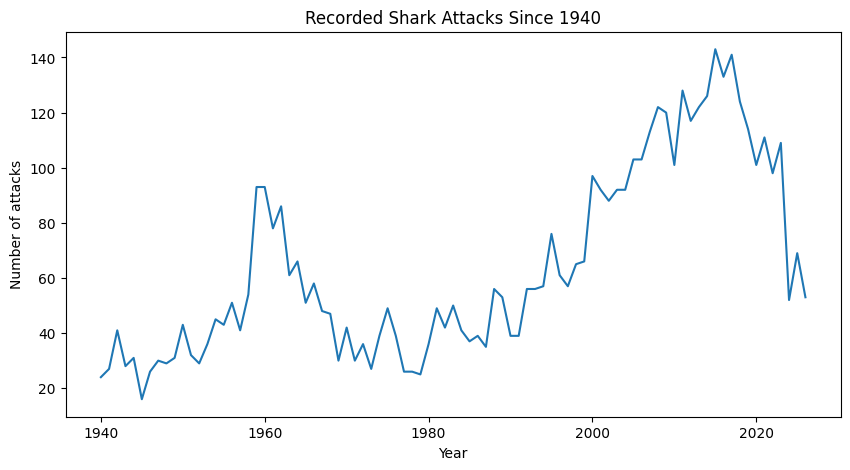

Average attacks per year in the 1940s: 28.3
Average attacks per year in the 2010s: 124.9


**************** Part 4 ****************
Age
NaN    1777
16       80
19       80
17       79
15       76
18       74
20       73
17       72
20       67
25       66
15       65
22       64
21       64
18       63
24       58
19       57
14       57
16       56
21       56
14       52
24       52
26       51
22       51
12       49
25       48
13       48
28       47
29       47
13       46
26       44
Name: count, dtype: int64
['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s']
count       3645.0
mean     28.6

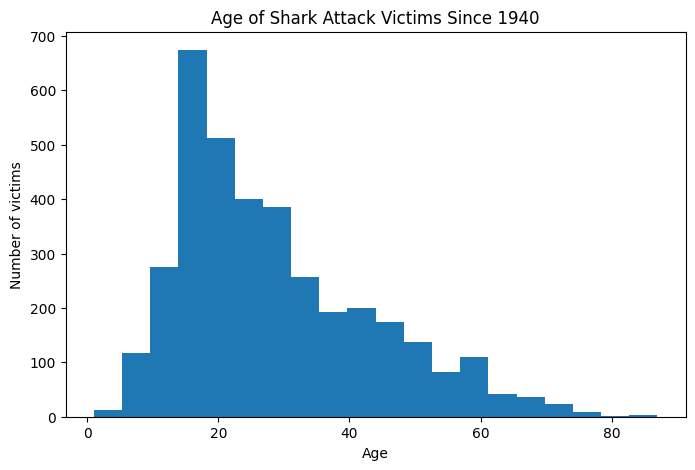



**************** Part 5 ****************
Sex
M        4384
F         730
NaN       451
M           7
?           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
Name: count, dtype: int64
Sex_clean
M       4393
F        732
<NA>     456
Name: count, dtype: Int64
Proportion male: 0.8571707317073171
Percent male: 85.71707317073171


**************** Part 6 ****************
Type
Unprovoked             4161
Provoked                526
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             27
NaN                      14
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type_clean
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: int64
Proportion unprovoked: 0.7459236695932628


In [49]:
# Q2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# 1. Open Excel file
print("**************** Part 1 ****************")
sharks = pd.read_excel("./data/GSAF5.xls")

print(sharks.shape)
print(sharks.columns)


# 2. Drop columns that do not contain useful data
print("\n\n**************** Part 2 ****************")

print(sharks.notna().sum())

# These are essentially empty unnamed columns
sharks = sharks.drop(columns=["Unnamed: 21", "Unnamed: 22"])


# 3. Clean Year
print("\n\n**************** Part 3 ****************")

# Inspect Year before clean
print(sharks["Year"].describe())
print(sharks["Year"].value_counts(dropna=False).sort_index().head(20))

# Create a numeric cleaned version
sharks["Year_clean"] = pd.to_numeric(
    sharks["Year"],
    errors="coerce"
)

# 0 is being used for cases where the exact year is unknown, so it will treat it as missing
sharks["Year_clean"] = sharks["Year_clean"].replace(0, np.nan)

print(sharks["Year_clean"].describe())


# Filter to attacks since 1940
sharks_recent = sharks[
    sharks["Year_clean"] >= 1940
].copy()

print("Number of attacks since 1940:", len(sharks_recent))


# Count attacks by year
attacks_by_year = (
    sharks_recent
    .groupby("Year_clean")
    .size()
)

# Plot attacks over time
plt.figure(figsize=(10, 5))
plt.plot(attacks_by_year.index, attacks_by_year.values)
plt.xlabel("Year")
plt.ylabel("Number of attacks")
plt.title("Recorded Shark Attacks Since 1940")
plt.show()

# Some summaries that help describe the trend
print(
    "Average attacks per year in the 1940s:",
    attacks_by_year.loc[1940:1949].mean()
)

print(
    "Average attacks per year in the 2010s:",
    attacks_by_year.loc[2010:2019].mean()
)


# 4. Clean Age and make a histogram
print("\n\n**************** Part 4 ****************")

# Inspect Age before cleaning
print(sharks_recent["Age"].value_counts(dropna=False).head(30))
print(sharks_recent["Age"].unique()[:100])

# Remove surrounding whitespace and convert valid numeric ages to numeric values. This will convert invalid ages to NaN
sharks_recent["Age_clean"] = pd.to_numeric(
    sharks_recent["Age"]
    .astype("string")
    .str.strip(),
    errors="coerce"
)

# describe cleaned Age va and count missing values
print(sharks_recent["Age_clean"].describe())
print(
    "Missing ages after cleaning:",
    sharks_recent["Age_clean"].isna().sum()
)

# Histogram
plt.figure(figsize=(8, 5))
plt.hist(
    sharks_recent["Age_clean"].dropna(),
    bins=20
)
plt.xlabel("Age")
plt.ylabel("Number of victims")
plt.title("Age of Shark Attack Victims Since 1940")
plt.show()


# 5. Proportion of victims who are male
print("\n\n**************** Part 5 ****************")

# Inspect Sex
print(sharks_recent["Sex"].value_counts(dropna=False))

# Standardize caps and whitespace
sex = (
    sharks_recent["Sex"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Only M and F are unambiguous values
sharks_recent["Sex_clean"] = sex.where(
    sex.isin(["M", "F"])
)

print(sharks_recent["Sex_clean"].value_counts(dropna=False))

# Calculate proportion male among victims with known M/F sex
male_proportion = (
    sharks_recent.loc[
        sharks_recent["Sex_clean"].notna(),
        "Sex_clean"
    ]
    .eq("M")
    .mean()
)

print("Proportion male:", male_proportion)
print("Percent male:", male_proportion * 100)


# 6. Clean Type
print("\n\n**************** Part 6 ****************")

# Inspect Type first
print(sharks_recent["Type"].value_counts(dropna=False))

type_text = (
    sharks_recent["Type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Keep Provoked and Unprovoked.
# Everything else is classified as Unknown.
sharks_recent["Type_clean"] = (
    type_text
    .map({
        "provoked": "Provoked",
        "unprovoked": "Unprovoked"
    })
    .fillna("Unknown")
)

print(sharks_recent["Type_clean"].value_counts())

unprovoked_proportion = (
    sharks_recent["Type_clean"]
    .eq("Unprovoked")
    .mean()
)

print("Proportion unprovoked:", unprovoked_proportion)
print("Percent unprovoked:", unprovoked_proportion * 100)

# Explanations

## Q1.1

The `Price` variable was initially an object instead of a numeric variable, and I saw that for prices greater than 999, there were commas, which prevented them from being recognized as numbers. I removed the commas and converted the variables to be numeric, and I saw that there were zero missing values before cleaning and zero missing values afterwards too. 

## Q1.2

When I inspected the `subject_injury` variable, I found that its only non-missing values were "yes" and "no". I standardized the variable by removing white space and restricting the valid observations to just those two categories. Anything outside of "yes" or "no" was considered missing.

The biggest issue was with missing data. There were 9,848 missing observations out of the 12,925 total, which meant that around 76.2% of the values were missing. This is extremely concerning because over three-fourths of the observations don't report if the subject was injured or not. This could lead to severe bias and unreliability with the data we have.

The cross-tabulation shows that missing injury information isn't evenly distributed across force types. For example, Less Lethal and Maximal Restraint Technique have missing injury information for all observations, while Chemical Irritant also has a very high missing rate. In contrast, Gun Point Display and Police K9 Bite have much lower proportions of missing injury data. The pattern suggests that the missingness could be related to the type of force, rather than it occurring generally across all observations. 

## Q2.1

The original dataset contained 7,117 observations in 23 columns. I examined how many non-missing observations there were in each column, and I found that unnamed 21 and unnamed 22 contained 1 and 2 non-missing values, respectively, and didn't even represent anything meaningful. As a result, I dropped those columns, but kept all the other columns, even if some of them contained some missing values. 

## Q2.3

I inspected the `Year` variable and found values ranging from 0 to 2026. The value 0 does not represent a meaningful calendar year and is used when the precise year is probably not available, so I converted the variable to numeric and replaced 0 with missing. After that, the years ranged from 5 to 2026. The very early years did represent very historical observations, so I didn't remove them, but I filtered the data to be observations from 1940 onwards, which left 5,581 attacks to use during the analysis. 

The plot shows that the number of shark attacks generally increased over time, but it's not a very constant pattern, and there is some variation. There are around 28.3 attacks per year in the 1940s, compared to around 124.9 attacks per year in the 2010s. 

## Q2.4

The Age variable has a mix of proper numeric ages but also nonnumeric values. I removed whitespace and marked entries without a single numerical age as missing. After this cleaning, 3,645 observations had numeric ages and 1,936 were missing.

The histogram shows shark attack victims mainly happens with younger people, especially teenagers and young adults. The largest concentration occurs around the mid-to-late teenage years, and the frequency generally goes down as age goes up. It is right-skewed, with a longer tail for older ages. The median age is 25 years, while the mean is approximately 28.6 years.

## Q2.5

The `Sex` variable contained mainly M and F, but also included inconsistent formatting and some ambiguous values. I removed whitespace, standardized capitalization, retained M and F observations, and treated anything else as missing. After cleaning, there were 4,393 male victims and 732 female victims, with 456 observations for which sex could not be confidently classified as either. Among victims whose sex was known as male or female, approximately 85.7% were male.

## Q2.6

I standardized capitalization and whitespace in `Type`, combined all versions of provoked and unprovoked attacks, and classified every other value as "Unknown". Approximately 74.6% of attacks since 1940 were unprovoked.

## *Phase 2: AI-assisted Revision
Keep Phase 1 frozen.

- **Phase 1 commit SHA ID:** 2937468c3f32332498f052aaf9ce443cc941bf40
- **AI tool and model used:** GPT-6 Astra via ChatGPT

### *Prompts used

1. Hello, I have given you access to my assignment A1 for my DS 3001 course. This assignment is a data wrangling assignment. Please pay attention to the file, "notebook.ipynb." I have completed Phase 1 on my own.&#x20;
Please firstly analyze the problems being asked for Phase 1. Understand what I was supposed to do and the associated data in the /data directory. Afterwards, examine the code I wrote and the associated output to my code.
After completely reviewing everything for Phase 1, you will be giving me revisions for Phase 2. Based on the questions, code, and output for Phase 1, what are the revisions you suggest to be incorporated in my code? Please identify mistakes, inconsistencies, and any possible fix you can give me to ensure my code and its output is efficient and correct.

2. Can you please view the code and output for Phase 2 that I created based on your revisions and verify that the revisions were all properly implemented and the overall code structure and accuracy is far better now? Please feel free to run the code yourself too to make sure everything works properly.

### *AI-proposed changes


1. **Q1.1 — Keep your price cleaning; add a conversion check.**  
   Removing commas before numeric conversion correctly handles prices such as `"1,112"`. I independently confirmed **30,478 records, zero missing cleaned prices, and a range of $10–$10,000**. There is no demonstrated error here.

   Because `errors="coerce"` silently converts unparseable values to missing, add a check for newly introduced missing values:
   ```python
   failed = (
       airbnb_hw["Price"].notna()
       & airbnb_hw["Price_cleaned"].isna()
   )
   print("Failed price conversions:", failed.sum())
   ```
   Do not remove expensive listings simply because they are outliers.

2. **Q1.2 — Keep missing injury values as missing, and add percentages within each force type.**  
   Your cleaning and overall missing proportion—**9,848 / 12,925 = 76.19%**—are correct. Your separate `"Missing"` category for the table is also appropriate; missing information should not be interpreted as `"No"`.

   Add a normalized table alongside the counts:
   ```python
   table = pd.crosstab(
       police_data["force_type"],
       police_data["subject_injury_table"]
   )
   print(table)
   print(table.div(table.sum(axis=1), axis=0).mul(100).round(2))
   ```
   This directly supports your explanation: missingness is **89.20% for Chemical Irritant**, **25.96% for Gun Point Display**, and **40.26% for Police K9 Bite**. Less Lethal and Maximal Restraint Technique are both 100% missing.

   Your conclusion about possible bias is reasonable. Explain that these patterns suggest an association with force type but do not establish why information is missing. Also correct the prose to use the actual categories `"Yes"` and `"No"`.

3. **Q2.2 — Distinguish empty columns from sparsely populated columns.**  
   The two dropped columns are **not empty**. I checked their contents:

   | Column | Nonmissing contents |
   |---|---|
   | `Unnamed: 21` | `"stopped here"` |
   | `Unnamed: 22` | `"Teramo"`, `"change filename"` |

   Use `sharks.dropna(axis=1, how="all")` for genuinely empty columns. In this file, that operation alone will not remove these two columns.

   Dropping them separately may be reasonable, but describe them as sparse, unlabeled fields containing apparent notes. The meaning of `"Teramo"` is not established, so the original claim that neither column contains anything meaningful is too strong.

4. **Q2.3 — Keep the year filter, but make the historical and trend explanations more precise.**  
   Converting zero to missing and filtering with `Year_clean >= 1940` is reasonable. The file has **129 zero years and two already missing years**, producing 131 missing years after your cleaning. The retained dataset contains **5,581 records**.

   I checked the unusually early entries: their dates include `"Ca. 5 A.D."`, `"Ca. 77 A.D."`, and `"Ca.789-1033 A.D"`. These support treating them as historical entries, but some dates are approximate.

   Your decade averages—28.3 versus 124.9—support a long-term increase in **recorded incidents**, with substantial fluctuations and lower recent counts. The file’s latest entries are in August 2026, so **2026 is a partial year**. Mark that point or exclude it from full-year comparisons. Do not interpret recorded counts alone as changes in an individual’s risk of attack.

5. **Q2.4 — Recover clear ages that numeric conversion currently discards.**  
   Your conservative treatment of ambiguous ages is defensible, but it also loses three clearly interpretable values present in the file:

   | Original value | Age in years |
   |---|---:|
   | `"18 months"` | 1.5 |
   | `"9 months"` | 0.75 |
   | `"6½"` | 6.5 |

   A targeted revision is:
   ```python
   age_text = sharks_recent["Age"].astype("string").str.strip()
   age_text = age_text.replace({
       "18 months": "1.5",
       "9 months": "0.75",
       "6½": "6.5",
   })
   sharks_recent["Age_clean"] = pd.to_numeric(
       age_text, errors="coerce"
   )
   ```
   With only these changes, usable ages increase from **3,645 to 3,648**, and missing ages decrease from **1,936 to 1,933**.

   Keep ranges, approximate descriptions, and multiple-person entries separate from exact ages. For example, `"30s"`, `"25 to 35"`, and `"28 & 22"` should not become exact ages through arbitrary digit extraction. Inspect suspicious entries such as `"!2"` before attempting corrections.

6. **Q2.4 — Explain what the histogram represents.**  
   Your saved histogram supports the description of a right-skewed distribution concentrated among teenagers and young adults. However, it represents **records with usable ages**, not every victim: approximately 34.7% of records lack usable ages under your original method, and some records describe multiple people.

   Label the vertical axis `"Number of records"` and mention the exclusions. Fixed five-year bins would also be easier to interpret than 20 automatically selected bins. Recompute the summary statistics after revising age cleaning.

7. **Q2.5 — Keep your sex cleaning, but make the denominator explicit in the printed result.**  
   Your **85.72%** calculation is correct **among the 5,125 records classified M or F**:

   $$
   4393 / (4393 + 732).
   $$

   Rename the output to `"Percent male among records with known M/F sex"`.

   There are also **456 unclassified records**. For comparison, 4,393 / 5,581 = **78.71% of all retained records are explicitly classified male**. These percentages answer different questions; neither establishes the sex distribution of the unknown records. Because entries such as `"M x 2"` exist, avoid claiming that your calculation counts individual victims precisely.

8. **Q2.6 — Keep your Type mapping and percentage, but explain “Unknown.”**  
   Your cleaning correctly produces **4,163 Unprovoked, 528 Provoked, and 890 Unknown** records. Thus **74.59% of all 5,581 retained records** are classified Unprovoked.

   Explain that `"Unknown"` is your assignment-required combined category: it includes `Invalid`, `Watercraft`, `Sea Disaster`, missing values, and other labels. It does not mean all 890 records originally lacked a type. Preserve the original `Type` column, as you already do.

9. **Organize and verify Phase 2 without changing Phase 1.**  
   Use separate cells for each subquestion, import packages once, and retain original variables alongside cleaned versions. State explicitly that Q2.4–Q2.6 use the since-1940 subset. Restart the kernel and run Phase 2 from top to bottom to verify that its outputs are reproducible.

### *Evaluation of AI suggestions


| Change | Decision | Reason and verification |
|---|---|---|
| 1 | **Accept** / modify / reject | I think this is a reasonable check to verify that my conversions occured successfully and did not introduce any new issues into the data. |
| 2 | **Accept** / modify / reject | I think it is extremely useful to add the percentage for each force type to understand the distribution of missing data better. |
| 3 | **Accept** / modify / reject | I suppose that I was only instructed to remove columns that do not contain any data, so I think it is probably best for me to not remove those columns without further analysis. I think they are still safe to remove, but they should not be treated/identified as empty columns. |
| 4 | **Accept** / modify / reject | I see no issues with enforcing more precision in the year selection. For example, I agree with the distinction that 2026 should not be counted as a full year like the rest of the years. |
| 5 | **Accept** / modify / reject | If there was a way to retain data that did not need to be discarded, I completely think that is acceptable. I could have been a little more thorough here. |
| 6 | **Accept** / modify / reject | I think it would be best to represent the histogram as accurately as possible. I see no issue with this suggestion. |
| 7 | **Accept** / modify / reject | Once again, another suggestion that encourages accurate reporting, and I am glad the AI caught these and allows my data to be more precise in the end. |
| 8 | **Accept** / modify / reject | I think it makes sense to treat Unknown as the combined category and adds accuracy/consistency by ensuring it is not reported that all those 890 values lacked a type. |
| 9 | **Accept** / modify / reject | This is a very general suggestion about the organization of the notebook that I respect and agree with, along with the suggestion that I should make sure it is known that the post 1940 data is used after that change. |

### *AI-assisted solution in full
After the evaluation of AI suggestions, incorporate the accepted revisions into your Phase 1 solution and provide the final Phase 2 solution in full in the following cells.

In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [51]:
# Q1.1
print("**************** Q1.1 ****************")

# Load airbnb data
airbnb_hw = pd.read_csv('data/airbnb_hw.csv')

# Check the data types and unique values of the Price variable
print("\nData types: ", airbnb_hw['Price'].dtype)
print("Unique values: ", airbnb_hw['Price'].unique()[:20])

# Check basic stats of the Price variable
print("\nBasic stats: ")
print(airbnb_hw['Price'].describe())

# Check first few rows of the Price variable
print("\nFirst few rows: ")
print(airbnb_hw['Price'].head())

# Check for missing values in the Price variable
print("\nMissing values before: ", airbnb_hw['Price'].isna().sum())

# Clean the 'Price' variable by removing commas and converting to numeric
airbnb_hw['Price_cleaned'] = (airbnb_hw['Price'].str.replace(',', '', regex=False))
airbnb_hw['Price_cleaned'] = pd.to_numeric(airbnb_hw['Price_cleaned'], errors='coerce')

# Check for failed conversions
failed = (
    airbnb_hw["Price"].notna()
    & airbnb_hw["Price_cleaned"].isna()
)
print("Failed price conversions:", failed.sum())
print("Unparsed prices:", airbnb_hw.loc[failed, "Price"].unique())

# Check the cleaned Price variable first feq rows
print("\nCleaned Price variable: ")
print(airbnb_hw['Price_cleaned'].head())

# Check the stats and check for missing values in the cleaned Price variable
print("\nCleaned Price variable stats: ")
print(airbnb_hw['Price_cleaned'].describe())
print("\nMissing values after: ", airbnb_hw['Price_cleaned'].isna().sum())


**************** Q1.1 ****************

Data types:  object
Unique values:  ['145' '37' '28' '199' '549' '149' '250' '90' '270' '290' '170' '59' '49'
 '68' '285' '75' '100' '150' '700' '125']

Basic stats: 
count     30478
unique      511
top         150
freq       1481
Name: Price, dtype: object

First few rows: 
0    145
1     37
2     28
3    199
4    549
Name: Price, dtype: object

Missing values before:  0
Failed price conversions: 0
Unparsed prices: []

Cleaned Price variable: 
0    145
1     37
2     28
3    199
4    549
Name: Price_cleaned, dtype: int64

Cleaned Price variable stats: 
count    30478.000000
mean       163.589737
std        197.785454
min         10.000000
25%         80.000000
50%        125.000000
75%        195.000000
max      10000.000000
Name: Price_cleaned, dtype: float64

Missing values after:  0


In [52]:
# Q1.2
print("\n\n**************** Q1.2 ****************")

# Load police data
police_data = pd.read_csv('data/mn_police_use_of_force.csv')

# Check data types and unique values of the subject_injury variable
print("\nUnique values: ", police_data['subject_injury'].unique())
print("Value counts: ", police_data['subject_injury'].value_counts(dropna=False))

# Clean the subject_injury  variable by stripping whitespace and converting to string
police_data["subject_injury_cleaned"] = (
    police_data["subject_injury"]
    .astype("string")
    .str.strip()
)

# Clean the subject_injury_cleaned variable by keeping only "Yes" and "No" values and settin others to NaN
police_data["subject_injury_cleaned"] = police_data["subject_injury_cleaned"].where(
    police_data["subject_injury_cleaned"].isin(["Yes", "No"]),
    pd.NA
)

# Missing indicator for subject_injury_cleaned
missing_proportion = police_data["subject_injury_cleaned"].isna().mean()
print("\nProportion missing:", missing_proportion)
print("Percent missing:", missing_proportion * 100)


# Make cross-tabulations
police_data["subject_injury_table"] = (
    police_data["subject_injury_cleaned"].fillna("Missing")
)

injury_counts = pd.crosstab(
    police_data["force_type"],
    police_data["subject_injury_table"]
).reindex(columns=["Missing", "No", "Yes"], fill_value=0)

injury_percentages = (
    injury_counts
    .div(injury_counts.sum(axis=1), axis=0)
    .mul(100)
)

print("\nInjury counts by force type:")
print(injury_counts)

print("\nInjury percentages within each force type:")
print(injury_percentages.round(2))



**************** Q1.2 ****************

Unique values:  [nan 'No' 'Yes']
Value counts:  subject_injury
NaN    9848
Yes    1631
No     1446
Name: count, dtype: int64

Proportion missing: 0.7619342359767892
Percent missing: 76.19342359767892

Injury counts by force type:
subject_injury_table         Missing    No   Yes
force_type                                      
Baton                              2     0     2
Bodily Force                    7051  1093  1286
Chemical Irritant               1421   131    41
Firearm                            0     2     0
Gun Point Display                 27    33    44
Improvised Weapon                 74    34    40
Less Lethal                       87     0     0
Less Lethal Projectile             0     1     2
Maximal Restraint Technique      170     0     0
Police K9 Bite                    31     2    44
Taser                            985   150   172

Injury percentages within each force type:
subject_injury_table         Missing      No   

In [53]:
# Q2.1 Open Excel file
print("**************** Q2.1 ****************")
sharks = pd.read_excel("./data/GSAF5.xls")

print(sharks.shape)
print(sharks.columns)

**************** Q2.1 ****************
(7117, 23)
Index(['Date', 'Year', 'Type', 'Country', 'State', 'Location', 'Activity',
       'Name', 'Sex', 'Age', 'Injury', 'Fatal Y/N', 'Time', 'Species ',
       'Source', 'pdf', 'href formula', 'href', 'Case Number', 'Case Number.1',
       'original order', 'Unnamed: 21', 'Unnamed: 22'],
      dtype='object')


In [54]:
# Q2.2 Drop columns that do not contain useful data
print("\n\n**************** Q2.2 ****************")

print(sharks.notna().sum())

# Remove columns that are genuinely empty.
empty_columns = sharks.columns[sharks.isna().all()].tolist()
print("Completely empty columns:", empty_columns)
sharks = sharks.dropna(axis=1, how="all")

# Inspect the sparse, unlabeled columns separately.
note_columns = [
    column
    for column in ["Unnamed: 21", "Unnamed: 22"]
    if column in sharks.columns
]

if note_columns:
    has_note = sharks[note_columns].notna().any(axis=1)

    print("\nNonmissing entries in sparse, unlabeled columns:")
    print(
        sharks.loc[
            has_note,
            ["Date", "Name"] + note_columns
        ].to_string(index=False)
    )

    # Exclude these sparse, unlabeled fields from this analysis.
    # The original Excel file retains their contents.
    sharks = sharks.drop(columns=note_columns)



**************** Q2.2 ****************
Date              7117
Year              7115
Type              7099
Country           7067
State             6630
Location          6550
Activity          6534
Name              6899
Sex               6539
Age               4123
Injury            7081
Fatal Y/N         6556
Time              3590
Species           3986
Source            7097
pdf               6799
href formula      6794
href              6796
Case Number       6798
Case Number.1     6797
original order    6799
Unnamed: 21          1
Unnamed: 22          2
dtype: int64
Completely empty columns: []

Nonmissing entries in sparse, unlabeled columns:
       Date              Name  Unnamed: 21     Unnamed: 22
13-Apr-2006 a sport fisherman stopped here             NaN
07-Jan-1952    Charles Thomas          NaN          Teramo
02-Sep-1878    Antonio du Val          NaN change filename




**************** Q2.3 ****************
count    7115.000000
mean     1936.549122
std       269.943193
min         0.000000
25%      1948.000000
50%      1987.000000
75%      2010.000000
max      2026.000000
Name: Year, dtype: float64
Year
0.0       129
5.0         1
77.0        1
1000.0      1
1500.0      1
1518.0      1
1543.0      1
1554.0      1
1555.0      1
1580.0      1
1595.0      1
1617.0      1
1637.0      1
1638.0      1
1640.0      1
1642.0      2
1691.0      1
1700.0      3
1703.0      1
1721.0      1
Name: count, dtype: int64
Missing years after cleaning: 131
count    6986.000000
mean     1972.308474
std        60.634293
min         5.000000
25%      1951.000000
50%      1988.000000
75%      2010.000000
max      2026.000000
Name: Year_clean, dtype: float64
Analysis scope: records dated 1940 onward.
Number of attacks since 1940: 5581


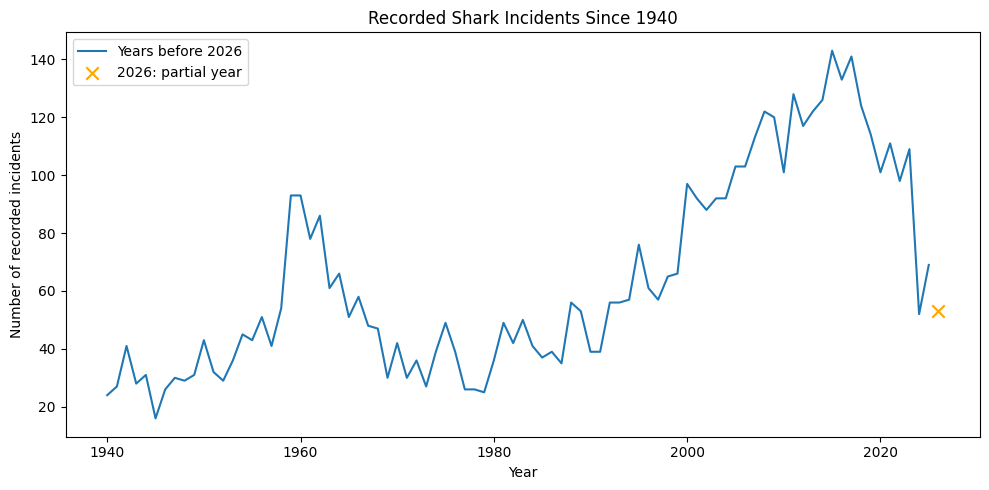

Average attacks per year in the 1940s: 28.3
Average attacks per year in the 2010s: 124.9


In [55]:
# Q2.3 Clean Year
print("\n\n**************** Q2.3 ****************")

# Inspect Year before clean
print(sharks["Year"].describe())
print(sharks["Year"].value_counts(dropna=False).sort_index().head(20))

# Create a numeric cleaned version
sharks["Year_clean"] = pd.to_numeric(
    sharks["Year"],
    errors="coerce"
)

# 0 is being used for cases where the exact year is unknown, so it will treat it as missing
sharks["Year_clean"] = sharks["Year_clean"].replace(0, np.nan)
print("Missing years after cleaning:", sharks["Year_clean"].isna().sum())

print(sharks["Year_clean"].describe())


# Filter to attacks since 1940
sharks_recent = sharks[
    sharks["Year_clean"] >= 1940
].copy()

# Q2.4–Q2.6 also use this since-1940 subset.
print("Analysis scope: records dated 1940 onward.")

print("Number of attacks since 1940:", len(sharks_recent))


# Count attacks by year
attacks_by_year = (
    sharks_recent
    .groupby("Year_clean")
    .size()
)

# This saved dataset contains only part of 2026.
partial_year = 2026
full_year_counts = attacks_by_year[
    attacks_by_year.index < partial_year
]

plt.figure(figsize=(10, 5))
plt.plot(
    full_year_counts.index,
    full_year_counts.values,
    label="Years before 2026"
)

if partial_year in attacks_by_year.index:
    plt.scatter(
        [partial_year],
        [attacks_by_year.loc[partial_year]],
        color="orange",
        marker="x",
        s=80,
        label="2026: partial year"
    )

plt.xlabel("Year")
plt.ylabel("Number of recorded incidents")
plt.title("Recorded Shark Incidents Since 1940")
plt.legend()
plt.tight_layout()
plt.show()

# Some summaries that help describe the trend
print(
    "Average attacks per year in the 1940s:",
    attacks_by_year.loc[1940:1949].mean()
)

print(
    "Average attacks per year in the 2010s:",
    attacks_by_year.loc[2010:2019].mean()
)





**************** Q2.4 ****************
Age
NaN    1777
16       80
19       80
17       79
15       76
18       74
20       73
17       72
20       67
25       66
15       65
22       64
21       64
18       63
24       58
19       57
14       57
16       56
21       56
14       52
24       52
26       51
22       51
12       49
25       48
13       48
28       47
29       47
13       46
26       44
Name: count, dtype: int64
['?' '43' '27' '71' '21' '69' '31' '13' '12' '17' '35' "20's" '19' '11'
 '20' '38' '39' '16' '22' '30+' "50's" '55' '26' '56' '24' '25' '61' '40'
 '14' '50+' '54' '48' '57' '8' '63' '9' '7' '85' '18' '66' '37' '42' '45'
 '30' '60' '40+' '29' 35 58 29 24 20 55 17 12 37 36 23 40 28 69 48 '60+'
 57 45 61 27 38 16 68 33 30 15 41 14 43 26 'Middle age' 18 21 49 25 46 19
 65 64 nan '46' '32' '10' '64' '62' '15' '52' '44' '47' '59' '50' '34'
 '30s']

Age entries not converted to exact numeric ages:
Age
?                          36
30s                        12
20s      

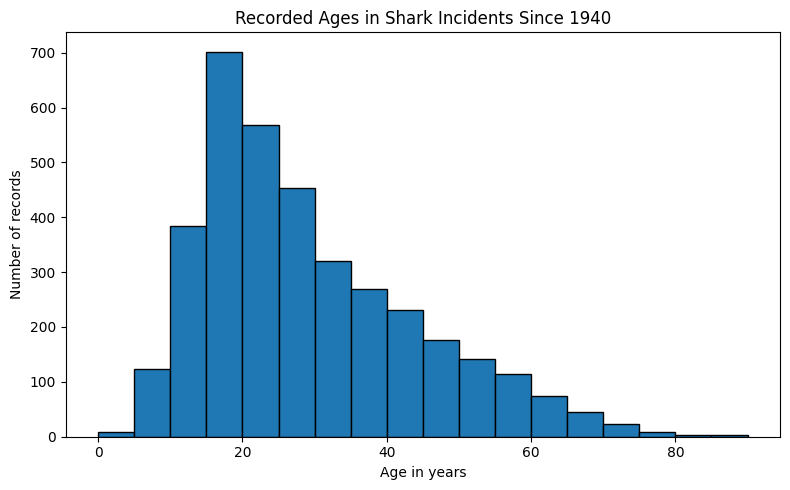

In [56]:
# Q2.4. Clean Age and make a histogram
print("\n\n**************** Q2.4 ****************")

# Inspect Age before cleaning
print(sharks_recent["Age"].value_counts(dropna=False).head(30))
print(sharks_recent["Age"].unique()[:100])

age_text = sharks_recent["Age"].astype("string").str.strip()

age_numeric_text = age_text.replace({
    "18 months": "1.5",
    "9 months": "0.75",
    "6½": "6.5",
})

sharks_recent["Age_clean"] = pd.to_numeric(
    age_numeric_text,
    errors="coerce"
)

# Inspect nonmissing source entries that remain unparsed.
unparsed_age = (
    age_text.notna()
    & sharks_recent["Age_clean"].isna()
)

print("\nAge entries not converted to exact numeric ages:")
print(age_text[unparsed_age].value_counts().to_string())

# describe cleaned Age va and count missing values
print(sharks_recent["Age_clean"].describe())
print(
    "Missing ages after cleaning:",
    sharks_recent["Age_clean"].isna().sum()
)

age_values = sharks_recent["Age_clean"].dropna()
missing_age_count = sharks_recent["Age_clean"].isna().sum()
missing_age_percent = sharks_recent["Age_clean"].isna().mean() * 100

print("Records included in histogram:", len(age_values))
print("Records excluded from histogram:", missing_age_count)
print(f"Percent excluded: {missing_age_percent:.2f}%")

# Five-year bins, extending beyond the largest observed age.
upper_edge = (int(age_values.max()) // 5 + 1) * 5
age_bins = np.arange(0, upper_edge + 1, 5)

plt.figure(figsize=(8, 5))
plt.hist(age_values, bins=age_bins, edgecolor="black")
plt.xlabel("Age in years")
plt.ylabel("Number of records")
plt.title("Recorded Ages in Shark Incidents Since 1940")
plt.tight_layout()
plt.show()

In [57]:
# Q2.5. Proportion of victims who are male
print("\n\n**************** Q2.5 ****************")

# Inspect Sex
print(sharks_recent["Sex"].value_counts(dropna=False))

# Standardize caps and whitespace
sex = (
    sharks_recent["Sex"]
    .astype("string")
    .str.strip()
    .str.upper()
)

# Only M and F are unambiguous values
sharks_recent["Sex_clean"] = sex.where(
    sex.isin(["M", "F"])
)

print(sharks_recent["Sex_clean"].value_counts(dropna=False))

male_count = int(sharks_recent["Sex_clean"].eq("M").sum())
female_count = int(sharks_recent["Sex_clean"].eq("F").sum())
known_sex_count = male_count + female_count
unknown_sex_count = int(sharks_recent["Sex_clean"].isna().sum())
total_records = len(sharks_recent)

male_proportion = male_count / known_sex_count
male_proportion_all = male_count / total_records

print("Male records:", male_count)
print("Female records:", female_count)
print("Unclassified sex records:", unknown_sex_count)

print(
    f"Percent male among records with known M/F sex: "
    f"{male_proportion * 100:.2f}% "
    f"({male_count}/{known_sex_count})"
)

print(
    f"Percent of all retained records explicitly classified male: "
    f"{male_proportion_all * 100:.2f}% "
    f"({male_count}/{total_records})"
)



**************** Q2.5 ****************
Sex
M        4384
F         730
NaN       451
M           7
?           2
F           2
M F         1
 M          1
m           1
lli         1
M x 2       1
Name: count, dtype: int64
Sex_clean
M       4393
F        732
<NA>     456
Name: count, dtype: Int64
Male records: 4393
Female records: 732
Unclassified sex records: 456
Percent male among records with known M/F sex: 85.72% (4393/5125)
Percent of all retained records explicitly classified male: 78.71% (4393/5581)


In [58]:
# Q2.6. Clean Type
print("\n\n**************** Q2.6 ****************")

# Inspect Type first
print(sharks_recent["Type"].value_counts(dropna=False))

type_text = (
    sharks_recent["Type"]
    .astype("string")
    .str.strip()
    .str.lower()
)

# Keep Provoked and Unprovoked.
# Everything else is classified as Unknown.
sharks_recent["Type_clean"] = (
    type_text
    .map({
        "provoked": "Provoked",
        "unprovoked": "Unprovoked"
    })
    .fillna("Unknown")
)

print(sharks_recent["Type_clean"].value_counts())

print("\nOriginal Type values grouped into Unknown:")
print(
    sharks_recent.loc[
        sharks_recent["Type_clean"].eq("Unknown"),
        "Type"
    ].value_counts(dropna=False)
)

unprovoked_proportion = (
    sharks_recent["Type_clean"]
    .eq("Unprovoked")
    .mean()
)

unprovoked_count = int(
    sharks_recent["Type_clean"].eq("Unprovoked").sum()
)

print(
    f"Percent of all retained records classified Unprovoked: "
    f"{unprovoked_proportion * 100:.2f}% "
    f"({unprovoked_count}/{len(sharks_recent)})"
)



**************** Q2.6 ****************
Type
Unprovoked             4161
Provoked                526
Invalid                 402
Watercraft              280
Sea Disaster            156
Questionable             27
NaN                      14
Boat                      7
 Provoked                 2
UNprovoked                1
unprovoked                1
?                         1
Unconfirmed               1
Unverified                1
Under investigation       1
Name: count, dtype: int64
Type_clean
Unprovoked    4163
Unknown        890
Provoked       528
Name: count, dtype: int64

Original Type values grouped into Unknown:
Type
Invalid                402
Watercraft             280
Sea Disaster           156
Questionable            27
NaN                     14
Boat                     7
?                        1
Unconfirmed              1
Unverified               1
Under investigation      1
Name: count, dtype: int64
Percent of all retained records classified Unprovoked: 74.59% (4163/5

### *Reflection on AI assistance
In your own words without generative AI.

[In 150–300 words, describe the main improvements, AI mistakes or limitations, how the final solution was verified, and any remaining concerns.]

I think that the AI assistant gave me a lot of great improvements to the code, mainly in terms of how I reported or displayed information and the organization of my code. I think these revisions were very useful, and they ensured that there was no confusion with what my code was outputting. I believe that a very important part of data science is how you properly report and communicate the data and your findings to those who see your analysis. I definitely think there was a lot of room for improvement with my original code. I really appreciated many suggestions from the AI, such as it fixing up my cross-tabulation and making sure it reported the different percentages for all the different types of forces, and how it fixed what the histogram represented. It also gave some great suggestions to improve my results themselves, such as how it tried to factor in the unnamed columns (which were ultimately removed in the end, but were still at least given more of an examination rather than being ignored altogether) and the proper identification of some numbers that were cut out and treated as missing before. I examined the revised code and its output, and I also asked the AI to examine it to ensure it was working properly. This process allowed me to find one more issue that I forgot to implement, which was actually still removing the two unnamed columns instead of keeping them. Overall, I think the AI did a great job of reviewing my work, and I think it's a great tool to use for debugging and catching mistakes. There were not any mistakes or limitations I caught, which makes sense since GPT-6 Astra is a very powerful model.